In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots

# Use science and IEEE style
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.figsize'] = 10, 6
plt.rcParams['font.size'] = 16
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']

# Define the color palette to use Orange and Blue explicitly
palette = {"ResNet + FeatUp": "tab:blue", "ViT + FeatUp": "tab:orange"}

# Load the first CSV
location = "/DISK/SemanticTestbed/logs/upsampling/log-resnet/50/metrics.csv"
df_resnet = pd.read_csv(location)

# Load the second CSV
location2 = "/DISK/SemanticTestbed/logs/upsampling/log-vit/50/metrics.csv"
df_vit = pd.read_csv(location2)

# Add a column to each dataframe to indicate the model type
df_resnet['Model'] = 'ResNet + FeatUp'
df_vit['Model'] = 'ViT + FeatUp'

# Concatenate the two dataframes vertically
df_combined = pd.concat([df_resnet, df_vit])

# Plotting histogram of LPIPS scores for both models with explicit colors
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='LPIPS', hue='Model', kde=True, stat="probability", bins=45, palette=palette)

plt.xlabel('LPIPS Score', fontsize=20)
plt.ylabel('Probability', fontsize=20)
# plt.title('Probability Distribution of LPIPS Scores', fontsize=18)
# plt.show()

output_file = "LPIPS_Scores.pdf"
plt.savefig(output_file, bbox_inches='tight', pad_inches=0.2, format='pdf', dpi=1200)
plt.close()  # Close the plot to free memory


In [7]:
import pandas as pd
import numpy as np

# Load the first CSV (replace with actual file paths if necessary)
location_resnet = "/DISK/SemanticTestbed/logs/upsampling/log-resnet/50/metrics.csv"
location_vit = "/DISK/SemanticTestbed/logs/upsampling/log-vit/50/metrics.csv"
df_resnet = pd.read_csv(location_resnet)
df_vit = pd.read_csv(location_vit)

# Create bins and calculate the histogram features
bins = np.histogram_bin_edges(pd.concat([df_resnet['LPIPS'], df_vit['LPIPS']]), bins=45)  # Same bin number as in your original code
bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers

# Calculate bin counts for each model
bin_counts_resnet = np.histogram(df_resnet['LPIPS'], bins=bins, density=False)[0]
bin_counts_vit = np.histogram(df_vit['LPIPS'], bins=bins, density=False)[0]

# Calculate probabilities
probabilities_resnet = bin_counts_resnet / bin_counts_resnet.sum()
probabilities_vit = bin_counts_vit / bin_counts_vit.sum()

# Create a DataFrame with the histogram features
df_histogram_features = pd.DataFrame({
    'LPIPS': bin_centers,
    'Probability_ResNet': probabilities_resnet,
    'Probability_ViT': probabilities_vit
})

# Save to CSV
output_csv = "histogram_features_LPIPS_grouped.csv"
df_histogram_features.to_csv(output_csv, index=False)

output_csv


'histogram_features_LPIPS_grouped.csv'

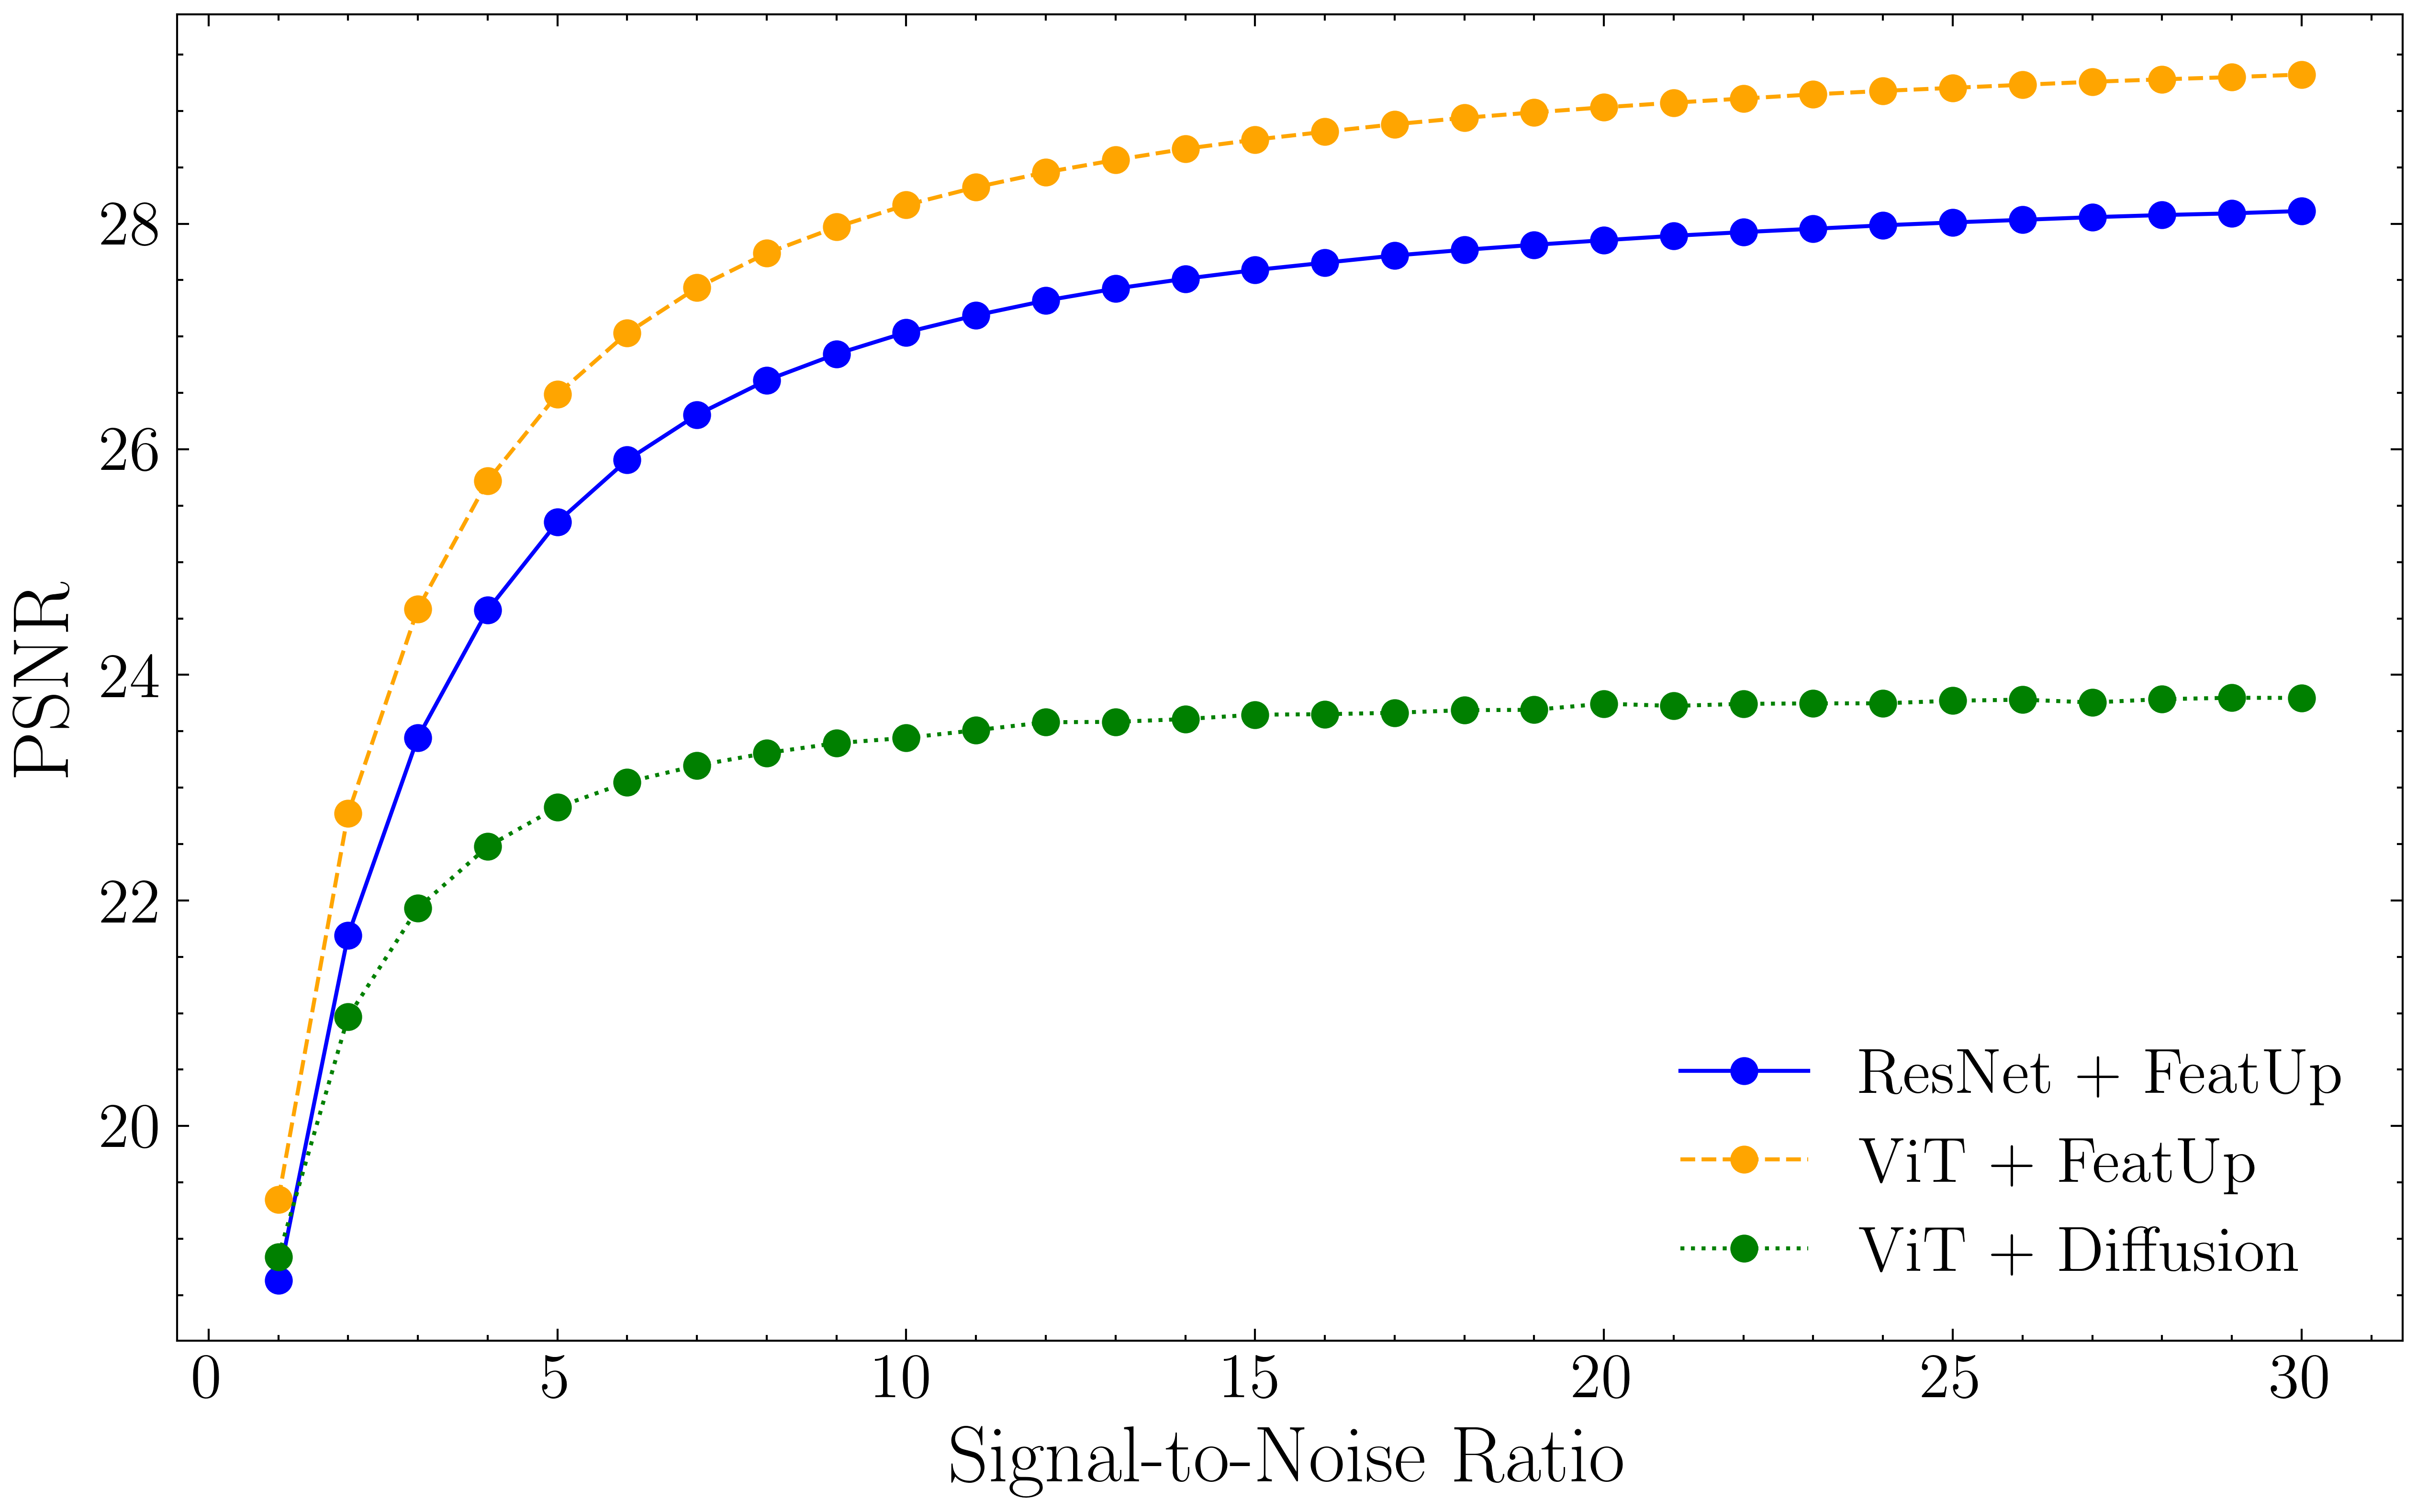

In [2]:
# Importing necessary libraries
import matplotlib.pyplot as plt
import scienceplots

# Use science and IEEE style
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.figsize'] = 10, 6
plt.rcParams['font.size'] = 16
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']

# Data for ResNet + FeatUp
psnr_resnet = [18.6314, 21.6911, 23.4436, 24.5744, 25.3544, 25.9047, 26.3057, 26.6124, 
               26.8449, 27.0370, 27.1885, 27.3188, 27.4250, 27.5124, 27.5894, 27.6545, 
               27.7180, 27.7687, 27.8132, 27.8538, 27.8929, 27.9259, 27.9553, 27.9859, 
               28.0116, 28.0348, 28.0583, 28.0770, 28.0922, 28.1131]

# Data for ViT + FeatUp
psnr_vit = [19.3489, 22.7708, 24.5851, 25.72, 26.4876, 27.0302, 27.4325, 27.7388, 
            27.9708, 28.1663, 28.3238, 28.4562, 28.5655, 28.6649, 28.7455, 28.8157, 
            28.8824, 28.939, 28.9875, 29.0325, 29.0736, 29.1102, 29.1471, 29.1779, 
            29.2048, 29.2322, 29.2588, 29.2805, 29.3001, 29.3228]

# Data for Diffusion (from the provided logs)
psnr_diffusion = [18.8403, 20.9673, 21.9318, 22.4781, 22.8260, 23.0484, 23.1967, 23.3071, 
                  23.3946, 23.4416, 23.5091, 23.5800, 23.5832, 23.6082, 23.6470, 23.6511, 
                  23.6639, 23.6871, 23.6900, 23.7447, 23.7245, 23.7431, 23.7471, 23.7475, 
                  23.7707, 23.7799, 23.7555, 23.7846, 23.7969, 23.7955]

snr = range(1, len(psnr_resnet) + 1)

# Plotting the line graph
plt.figure(figsize=(10, 6))

plt.plot(snr, psnr_resnet, label='ResNet + FeatUp', color='blue', marker='o')
plt.plot(snr, psnr_vit, label='ViT + FeatUp', color='orange', marker='o')
plt.plot(snr, psnr_diffusion, label='ViT + Diffusion', color='green', marker='o')

# Adding labels and title
plt.xlabel('Signal-to-Noise Ratio', fontsize=20)
plt.ylabel('PSNR', fontsize=20)
plt.legend()

# Displaying the plot
output_file = "PSNR_Scores.pdf"
plt.savefig(output_file, bbox_inches='tight', pad_inches=0.2, format='pdf', dpi=1200)
plt.show()


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots.styles
import glob
import os

plt.style.use(['science', 'ieee'])
plt.rcParams['figure.figsize'] = 10, 6
plt.rcParams['font.size'] = 20
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']

# Use Latex RGB color
RED = '#FF1A14'
GREEN = '#008000'
BLUE = '#0000FF'
BLACK = '#000000'
DARKGREEN = '#006400'

# Set the style colors of IEEE
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[BLUE, RED])

# Directory containing the CSV files
csv_file = '/DISK/SemanticTestbed/logs/classification/30/qvit/cm_epoch150.csv'


df = pd.read_csv(csv_file)

# Create a heatmap using seaborn
plt.figure(figsize=(9, 8))
ax = sns.heatmap(df, annot=False, cbar=True, cmap='Purples', fmt='d', yticklabels=True, xticklabels=True, vmin=0, vmax=120)

cbar = ax.collections[0].colorbar
cbar.set_ticks([0, 20, 40, 60, 80, 100, 120])
# cbar.ax.tick_params(labelsize=20)

plt.xlabel("Predicted Class", fontsize=20)
plt.ylabel("Ground Truth Class", fontsize=20)

# Generate the output file name
output_file = "CM.pdf"
plt.savefig(output_file, bbox_inches='tight', pad_inches=0.2, format='pdf', dpi=1200)
plt.close()  # Close the plot to free memory




In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots.styles
import glob
import os

plt.style.use(['science', 'ieee'])
plt.rcParams['figure.figsize'] = 10, 6
plt.rcParams['font.size'] = 20
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']

# Use Latex RGB color
RED = '#FF1A14'
GREEN = '#008000'
BLUE = '#0000FF'
BLACK = '#000000'
DARKGREEN = '#006400'

# Set the style colors of IEEE
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[BLUE, RED])

# Directory containing the CSV files
csv_file = '/DISK/SemanticTestbed/logs/classification/30/resnet/cm_epoch150.csv'

df = pd.read_csv(csv_file)

# Create a heatmap using seaborn
plt.figure(figsize=(9, 8))
ax = sns.heatmap(df, annot=False, cbar=True, cmap='Blues', fmt='d', yticklabels=True, xticklabels=True, vmin=0, vmax=120)
ax.set_xticklabels(['' for _ in ax.get_xticks()])
ax.set_yticklabels(['' for _ in ax.get_yticks()])
cbar = ax.collections[0].colorbar
cbar.set_ticks(cbar.get_ticks())  # Keep the ticks
cbar.ax.set_yticklabels([])

# cbar.ax.tick_params(labelsize=20)

# plt.xlabel("Predicted Class", fontsize=20)
# plt.ylabel("Ground-Truth Class", fontsize=20)

# Generate the output file name
output_file = "CM.pdf"
plt.savefig(output_file, bbox_inches='tight', pad_inches=0.2, format='pdf', dpi=1200)
plt.close()  # Close the plot to free memory


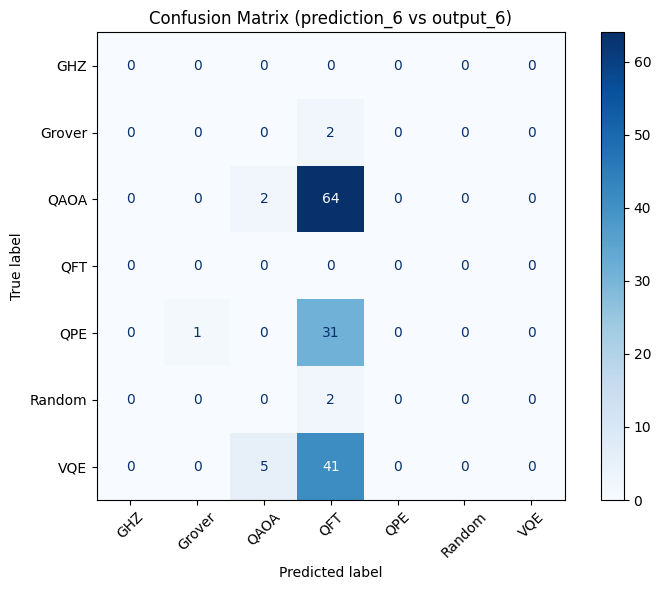

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load CSV (adjust the path if needed)
df = pd.read_csv("/DISK/QuantumVLM/Result/case_study_circuit_patched_inference_chkt2440.csv")

# Extract the relevant columns
y_true = df["output_6"]
y_pred = df["prediction_6"]

# Define the fixed set of labels
labels = ["GHZ", "Grover", "QAOA", "QFT", "QPE", "Random", "VQE"]

# Build the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")

plt.title("Confusion Matrix (prediction_6 vs output_6)")
plt.tight_layout()
plt.show()


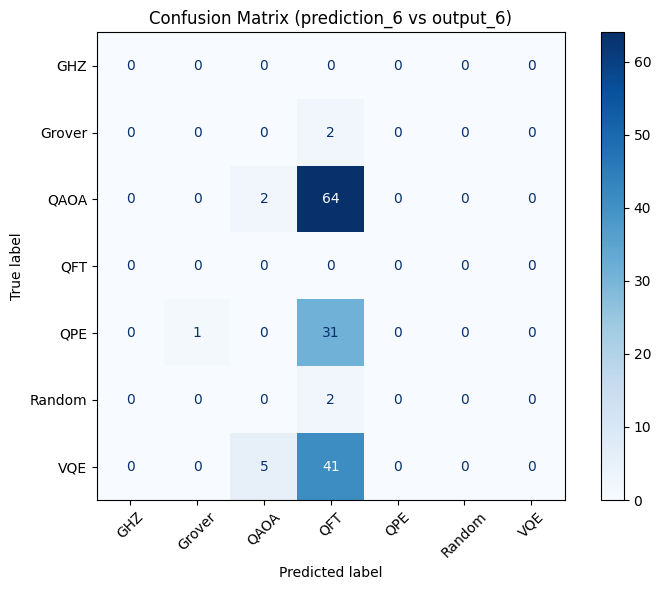

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load CSV (adjust the path if needed)
df = pd.read_csv("/DISK/QuantumVLM/Result/case_study_circuit_patched_inference_chkt2440.csv")

# Extract the relevant columns
y_true = df["output_6"]
y_pred = df["prediction_6"]

# Define the fixed set of labels
labels = ["GHZ", "Grover", "QAOA", "QFT", "QPE", "Random", "VQE"]

# Build the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")

plt.title("Confusion Matrix (prediction_6 vs output_6)")
plt.tight_layout()
plt.show()
